In [1]:
import pandas as pd
import numpy as np
import os

In [55]:
df_stack_21 = pd.read_csv("data/stack-overflow-developer-survey-2021.csv")
df_stack_21.head(10)

,ResponseId,MainBranch,Employment,Country,US_State,UK_Country,EdLevel,Age1stCode,LearnCode,YearsCode,...,Age,Gender,Trans,Sexuality,Ethnicity,Accessibility,MentalHealth,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Slovakia,NaN,NaN,"Secondary school (e.g. American high school, G...",18 - 24 years,Coding Bootcamp;Other online resources (ex: vi...,NaN,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,62268.0
1,2,I am a student who is learning to code,"Student, full-time",Netherlands,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",7,...,18-24 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,NaN
2,3,"I am not primarily a developer, but I write co...","Student, full-time",Russian Federation,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,...,18-24 years old,Man,No,Prefer not to say,Prefer not to say,None of the above,None of the above,Appropriate in length,Easy,NaN
3,4,I am a developer by profession,Employed full-time,Austria,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,NaN,NaN,...,35-44 years old,Man,No,Straight / Heterosexual,White or of European descent,I am deaf / hard of hearing,NaN,Appropriate in length,Neither easy nor difficult,NaN
4,5,I am a developer by profession,"Independent contractor, freelancer, or self-em...",United Kingdom of Great Britain and Northern I...,NaN,England,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5 - 10 years,Friend or family member,17,...,25-34 years old,Man,No,NaN,White or of European descent,None of the above,NaN,Appropriate in length,Easy,NaN
5,6,I am a student who is learning to code,"Student, part-time",United States of America,Georgia,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,...,18-24 years old,Prefer not to say,No,Straight / Heterosexual,Prefer not to say,None of the above,I have a concentration and/or memory disorder ...,Too long,Neither easy nor difficult,NaN
6,7,I code primarily as a hobby,I prefer not to say,United States of America,New Hampshire,NaN,"Secondary school (e.g. American high school, G...",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",3,...,Prefer not to say,Prefer not to say,No,NaN,I don't know,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,NaN
7,8,I am a student who is learning to code,"Student, full-time",Malaysia,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,School;Online Courses or Certification,4,...,18-24 years old,Woman,No,Straight / Heterosexual,White or of European descent;Multiracial;South...,None of the above,None of the above,Appropriate in length,Easy,NaN
8,9,I am a developer by profession,Employed part-time,India,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18 - 24 years,Coding Bootcamp,6,...,25-34 years old,Man,No,NaN,South Asian,NaN,I have a concentration and/or memory disorder ...,Appropriate in length,Easy,NaN
9,10,I am a developer by profession,Employed full-time,Sweden,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,School,7,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,51552.0


In [3]:
df_stack_21.info()

<class 'pandas.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    83439 non-null  int64  
 1   MainBranch                    83439 non-null  str    
 2   Employment                    83323 non-null  str    
 3   Country                       83439 non-null  str    
 4   US_State                      14920 non-null  str    
 5   UK_Country                    4418 non-null   str    
 6   EdLevel                       83126 non-null  str    
 7   Age1stCode                    83243 non-null  str    
 8   LearnCode                     82963 non-null  str    
 9   YearsCode                     81641 non-null  str    
 10  YearsCodePro                  61216 non-null  str    
 11  DevType                       66484 non-null  str    
 12  OrgSize                       60726 non-null  str    
 13  Currency    

In [4]:
# obtrener los distintos valores de la columna "MainBranch"
df_stack_21["MainBranch"].unique()

<StringArray>
[                                               'I am a developer by profession',
                                        'I am a student who is learning to code',
 'I am not primarily a developer, but I write code sometimes as part of my work',
                                                   'I code primarily as a hobby',
                      'I used to be a developer by profession, but no longer am',
                                                                 'None of these']
Length: 6, dtype: str

In [5]:
#descartamos 'I code primarily as a hobby', 'I used to be a developer... but no longer am' y 'None of these'

interesantes = [
    'I am a developer by profession',
    'I am a student who is learning to code',
    'I am not primarily a developer, but I write code sometimes as part of my work'
]

# Filtramos el DataFrame
df_stack_21_dedicacion = df_stack_21[df_stack_21['MainBranch'].isin(interesantes)]
df_stack_21_dedicacion.shape

(76760, 48)

In [6]:
df_stack_dedicacion_spain_2021 = df_stack_21_dedicacion[df_stack_21_dedicacion["Country"].values == "Spain"]
print(df_stack_dedicacion_spain_2021.shape)

(1407, 48)


In [7]:
df_stack_22 = pd.read_csv("data/stack-overflow-developer-survey-2022.csv")
df_stack_23 = pd.read_csv("data/stack-overflow-developer-survey-2023.csv")
df_stack_24 = pd.read_csv("data/stack-overflow-developer-survey-2024.csv")
df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")

C:\Users\jlalo\AppData\Local\Temp\ipykernel_13244\2924736885.py:4: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")


Hacemos el mismo proceso con el resto de datasets para filtra los datos que nos interesan.

In [8]:
df_stack_25.shape

(49191, 172)

In [9]:
#hacemos el mismo proceso de filtrado sobre dedicación y país para los otros años

years = [2022, 2023, 2024, 2025]
array_dfs = [df_stack_22, df_stack_23, df_stack_24, df_stack_25]

for year, df in zip(years, array_dfs):
    df_dedicacion = df[df['MainBranch'].isin(interesantes)]
    globals()[f"df_stack_dedicacion_spain_{year}"] = df_dedicacion[df_dedicacion["Country"].values == "Spain"]

In [10]:
df_stack_dedicacion_spain_2022.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
87,88,I am a developer by profession,"Employed, full-time",Fully remote,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Blogs;Stack Overflow,NaN,13,...,30-60 minutes a day,30-60 minutes a day,Somewhat long,DevOps function;Microservices;Continuous integ...,Yes,Yes,Yes,Appropriate in length,Easy,95979.0
109,110,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,Some college/university study without earning ...,Books / Physical media;Other online resources ...,Technical documentation;Written Tutorials;Stac...,Udemy;Pluralsight,10,...,Over 120 minutes a day,Less than 15 minutes a day,Very long,DevOps function;Developer portal or other cent...,No,No,No,Too long,Neither easy nor difficult,44790.0
245,246,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","School (i.e., University, College, etc)",NaN,NaN,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,26128.0
311,312,I am a developer by profession,"Employed, full-time",Full in-person,Hobby,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,NaN,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,49056.0
431,432,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,Some college/university study without earning ...,Books / Physical media;Other online resources ...,Technical documentation;Blogs;Written Tutorial...,Udemy;Codecademy;Udacity;Other,9,...,60-120 minutes a day,15-30 minutes a day,Very short,Automated testing,No,No,Yes,Appropriate in length,Easy,31993.0


In [23]:
# Lista de columnas maestras que queremos
# Columnas que vamos a extraer de cada año (si existen)
columnas_interes = {
    'MainBranch': 'Dedicacion',
    'Country': 'Pais',
    'Age' : 'Edad',
    'YearsCodePro': 'Años_programando',
    'LanguageHaveWorkedWith': 'Lenguajes_uso',
    'LanguageWantToWorkWith': 'Lenguajes_deseo',
    'LearnCode': 'Metodo_aprendizaje',
    'LearnCodeOnline': 'Metodo_aprendizaje_online',
    'ConvertedCompYearly': 'Salario_anual',
    'AISentiment': 'IA_sentimiento',
    'AIToolCurrentlyUsing': 'IA_herramientas',
    'AIAgentExternal': 'IA_herramientas_Externas' # Mapeamos la de 2025 a la genérica
}

# Al cargar cada año:
def load_and_standardize(year_file, year_label):
    df = pd.read_csv(year_file, low_memory=False)
    existing_cols = [c for c in columnas_interes.keys() if c in df.columns] # Solo nos quedamos con las columnas que existen en columnas_interes
    df = df[existing_cols].copy()
    df.rename(columns=columnas_interes, inplace=True)
    #filtramos por dedicación para reducir el tamaño del DataFrame
    df = df[df['Dedicacion'].isin(interesantes)]
    df['Year'] = year_label
    return df

def filter_by_country(df, country="Spain"):
    return df[df['Pais'].values == country]

years = [2021, 2022, 2023, 2024, 2025]
dfs = [load_and_standardize(f"data/stack-overflow-developer-survey-{y}.csv", y) for y in years]

df_master_total = pd.concat(dfs, axis=0, ignore_index=True)
df_master = filter_by_country(df_master_total, "Spain")


In [24]:
print(f"totales: {df_master_total.shape}")
print(f"filtrados por país: {df_master.shape}")

totales: (290972, 11)
filtrados por país: (5751, 11)


In [25]:
df_master.head(10)

,Dedicacion,Pais,Edad,Años_programando,Lenguajes_uso,Lenguajes_deseo,Metodo_aprendizaje,Salario_anual,Year,Metodo_aprendizaje_online,IA_herramientas_Externas
10,I am a developer by profession,Spain,25-34 years old,5,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,C++;Clojure;JavaScript;Node.js;Rust;SQL;TypeSc...,"Other online resources (ex: videos, blogs, etc...",46482.0,2021,NaN,NaN
59,I am a developer by profession,Spain,35-44 years old,10,Bash/Shell;JavaScript;Node.js;TypeScript,JavaScript;Node.js;Python;TypeScript,School,58373.0,2021,NaN,NaN
70,I am a developer by profession,Spain,18-24 years old,NaN,C#;Go;Java;Python,C++;Clojure;Go;Rust,Online Courses or Certification,21620.0,2021,NaN,NaN
98,I am a developer by profession,Spain,25-34 years old,8,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL;Ty...,Coding Bootcamp;School,38915.0,2021,NaN,NaN
242,I am a developer by profession,Spain,35-44 years old,13,HTML/CSS;Java;JavaScript;Node.js;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,Other (please specify):,NaN,2021,NaN,NaN
244,I am a developer by profession,Spain,25-34 years old,4,Bash/Shell;C;C++;HTML/CSS;Java;JavaScript;Node...,Bash/Shell;HTML/CSS;Java;JavaScript;Node.js;PH...,Online Forum,NaN,2021,NaN,NaN
270,I am a developer by profession,Spain,25-34 years old,5,Kotlin;Python,Kotlin;Python,"Other online resources (ex: videos, blogs, etc...",32429.0,2021,NaN,NaN
271,I am a developer by profession,Spain,25-34 years old,10,Assembly;Bash/Shell;C;C#;C++;Go;HTML/CSS;Java;...,Bash/Shell;C#;C++;Crystal;Dart;Delphi;Elixir;E...,Coding Bootcamp;Other online resources (ex: vi...,12972.0,2021,NaN,NaN
274,I am a developer by profession,Spain,25-34 years old,4,C#;JavaScript;Kotlin;TypeScript,C#;JavaScript;Kotlin;SQL;TypeScript,"Other online resources (ex: videos, blogs, etc...",28105.0,2021,NaN,NaN
350,I am a developer by profession,Spain,25-34 years old,10,Bash/Shell;JavaScript;Python;SQL,C++,Coding Bootcamp;Other online resources (ex: vi...,64860.0,2021,NaN,NaN


In [27]:
# creamos una lista de los lenguajes usados y deseados
languages_usados = df_master['Lenguajes_uso'].dropna().str.split(';').explode().unique()
languages_deseados = df_master['Lenguajes_deseo'].dropna().str.split(';').explode().unique()
total_languages = set(languages_usados) | set(languages_deseados)

In [29]:
#guardamos en un diccionario los lenguajes más populares contando las veces en salen en los lenguajes usados y deseados
used_languages = {}
desired_languages = {}
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts()) 

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))

    

In [30]:
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Bash/Shell (all shells): 1625 menciones
Kotlin: 1424 menciones
C: 1404 menciones
Bash/Shell: 1293 menciones


Aqui observamos que "Bash/Shell" y "Bash/Shell (all shells)" es el mismo conecto pero está dupliaco en dos filas.
Deberíamos unificar este criterio para sumar sus menciones.

In [34]:
# Definimos el mapeo de lo que queremos cambiar
mapeo_shell = {
    'Bash/Shell (all shells)': 'Bash/Shell'
}

# Reemplazamos en ambas columnas
# Usamos regex=False para que trate el paréntesis como texto normal y no como comando de búsqueda
df_master['Lenguajes_uso'] = df_master['Lenguajes_uso'].str.replace('Bash/Shell (all shells)', 'Bash/Shell', regex=False)
df_master['Lenguajes_deseo'] = df_master['Lenguajes_deseo'].str.replace('Bash/Shell (all shells)', 'Bash/Shell', regex=False)

Volvemos a contar para verificar que el cambio se ha aplicado correctamente

In [35]:
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts())

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
Bash/Shell: 2918 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Kotlin: 1424 menciones
C: 1404 menciones
PowerShell: 878 menciones


Vamos a crear un nuevo DataFrame con los lenguajes más populares y el número de menciones en uso y deseo y el ratio de Hype_Ratio. El Hype_Ratio se calcula como el número de menciones en deseo dividido por el número de menciones en uso, para ver qué lenguajes tienen más hype en relación a su uso actual.
El DataFrame tendrá las columnas: 'Lenguaje', 'Uso', 'Deseo' y 'Hype_Ratio'.

In [36]:
#vamos a crear un nuevo DataFrame con los lenguajes más populares y el número de menciones en uso y deseo y el ratio de Hype_Ratio
df_popular_languages = pd.DataFrame({
    'Lenguaje': list(popular_languages.keys()),
    'Uso': [used_languages[lang] for lang in popular_languages.keys()],
    'Deseo': [desired_languages[lang] for lang in popular_languages.keys()],
    'Hype_Ratio': [desired_languages[lang] / used_languages[lang] if used_languages[lang] > 0 else 0 for lang in popular_languages.keys()]
})
df_popular_languages.sort_values(by='Hype_Ratio', ascending=False, inplace=True)
df_popular_languages


,Lenguaje,Uso,Deseo,Hype_Ratio
55,Mojo,1,8,8.000000
34,Zig,19,137,7.210526
49,Gleam,5,21,4.200000
53,APL,3,12,4.000000
33,Julia,38,124,3.263158
11,Rust,403,1256,3.116625
57,Zephyr,1,3,3.000000
36,F#,37,105,2.837838
35,Solidity,43,102,2.372093
42,OCaml,21,46,2.190476


Vemos que los lenguajes con mayor Hype_Ratio son aquellos que tienen un número relativamente bajo de usuarios actuales pero un número alto de personas que quieren aprenderlo,
lo que indica que son lenguajes emergentes o en tendencia. 
Por ejemplo, Rust, Go y Dart tienen un Hype_Ratio muy alto, lo que sugiere que aunque no son los más usados actualmente, hay un gran interés en aprenderlos. 

Por otro lado, lenguajes como JavaScript, Python y Java tienen un Hype_Ratio más bajo, lo que indica que aunque son muy populares, el interés en aprenderlos no es tan alto en comparación con su uso actual.

Por último podemos apreciar que lenguajes como PHP, o Cobol tienen un Hype_Ratio muy bajo, lo que sugiere que aunque todavía tienen una base de usuarios, 
el interés en aprenderlos es muy bajo, lo que podría indicar que están en declive.

In [37]:
df_popular_languages.sort_values(by='Deseo', ascending=False, inplace=True)
df_popular_languages    


,Lenguaje,Uso,Deseo,Hype_Ratio
0,JavaScript,3641,2320,0.637188
2,Python,2601,2291,0.880815
1,SQL,2989,1998,0.668451
4,TypeScript,2074,1925,0.928158
3,HTML/CSS,2967,1902,0.641052
11,Rust,403,1256,3.116625
5,Java,2163,1170,0.540915
9,Go,584,1151,1.970890
6,Bash/Shell,1803,1115,0.618414
7,C#,1293,947,0.732405


In [38]:
df_trends = pd.read_csv("data/tendencias_lenguajes.csv")
df_trends.head()

,Time,JavaScript,SQL,Python,HTML,TypeScript,Java,C Sharp,PHP
0,2021-04-01,16,8,28,11,0,19,5,8
1,2021-05-01,16,10,25,11,0,23,6,8
2,2021-06-01,15,7,27,12,0,19,5,6
3,2021-07-01,14,7,25,9,0,15,5,5
4,2021-08-01,11,6,24,7,0,18,5,6


Ahora vamos a empezar a pintar gráficas.
Primero pintaremos una gráfica que refleje el crecimiento en popularidad de encuesta de Stack mostrando el número de encuestas totales frente a las realizadas en España en un gráfica de barras a dos colores.

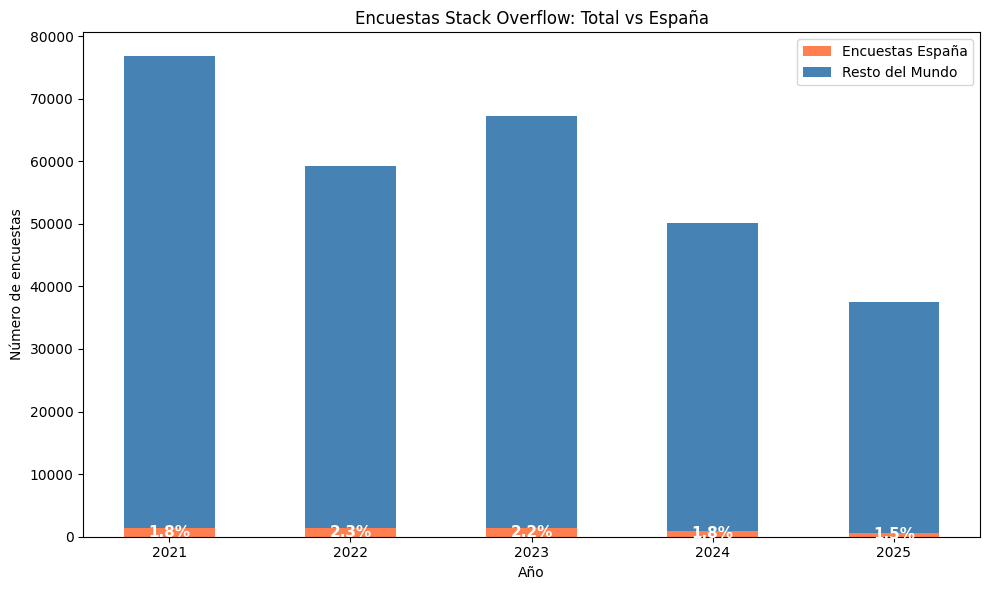

In [39]:
import matplotlib.pyplot as plt

df_plot = df_master_total.groupby('Year').size().reset_index(name='Total_Encuestas') #contamos el número de encuestas por año
df_plot_spain = df_master.groupby('Year').size().reset_index(name='Encuestas_España') #contamos el número de encuestas por año para España
df_plot = df_plot.merge(df_plot_spain, on='Year', how='left') #hacemos un merge para juntar ambos DataFrames
df_plot['Resto_Mundo'] = df_plot['Total_Encuestas'] - df_plot['Encuestas_España'] #calculamos el número de encuestas del resto del mundo
df_plot['Porcentaje_España'] = (df_plot['Encuestas_España'] / df_plot['Total_Encuestas']) * 100 #calculamos el porcentaje de encuestas de España

fig, ax = plt.subplots(figsize=(10, 6)) #creamos la figura y el eje para el gráfico
x = range(len(df_plot))
width = 0.5

# Barra de España abajo
bars_spain = ax.bar(x, df_plot['Encuestas_España'], width, label='Encuestas España', color='coral')
# Barra del resto del mundo apilada encima
bars_resto = ax.bar(x, df_plot['Resto_Mundo'], width, bottom=df_plot['Encuestas_España'], label='Resto del Mundo', color='steelblue')

# Añadir el porcentaje dentro de las barras de España
for i, (bar, pct) in enumerate(zip(bars_spain, df_plot['Porcentaje_España'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{pct:.1f}%',
            ha='center', va='center', fontweight='bold', color='white', fontsize=11)

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['Year'].astype(int))
ax.set_xlabel('Año')
ax.set_ylabel('Número de encuestas')
ax.legend()
ax.set_title('Encuestas Stack Overflow: Total vs España')
plt.tight_layout()
plt.show()

En la grágica podemos ver como a partir, sobre todo, con el auge de los LLMs el numero de encuestas se ha reducido drasticamente ya que desde entonces Stack Overflow ha mostrado un enorme descenso de visualizaciones y realizacióln de nuevas consultas debido a la gente acude directamente a consultar a IA como es muestra en este grafico.

![Evolución Stack Overflow](img/nuevas-consultas-Stack-Overflow.png)

Fuente de los datos: [Stack Exchange Data Explorer](https://data.stackexchange.com/)

Se aprecia una fase de crecimiento de 2008 a 2014, una segunda fase de consolidación hasta 2022 y por último un brusco descenso desde 2022 hasta hoy, coincidiendo con la aparicion de los grandes modelos de Lenguage como ChatGPT y volviendo a los niveles de su comienzo en 2008.


In [ ]:
# %pip install pycountry

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB 660.6 kB/s eta 0:00:13
   ---------------------------------------- 0.1/8.0 MB 1.1 MB/s eta 0:00:08
   - -------------------------------------- 0.3/8.0 MB 2.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/8.0 MB 2.0 MB/s eta 0:00:04
   --- ------------------------------------ 0.6/8.0 MB 2.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.6/8.0 MB 2.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.6/8.0 MB 1.9 MB/s eta 0:00:04
   ---- ----------------------------------- 0.9/8.0 MB 2.5 MB/s eta 0:00:03
   ---- ----------------------------------- 0.9/8.0 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.1/8.0 MB 2.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.5/8.0 MB 2.9 MB/s eta 0:00:03
   -------- ------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
geo_df[geo_df['ISO-3'].isna()]['Pais'].tolist()

['United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
 'Turkey',
 'Czech Republic',
 'Iran, Islamic Republic of...',
 'Taiwan',
 'South Korea',
 'Hong Kong (S.A.R.)',
 'Venezuela, Bolivarian Republic of...',
 'Republic of Korea',
 'Republic of Moldova',
 'Nomadic',
 'Bolivia',
 'The former Yugoslav Republic of Macedonia',
 'Kosovo',
 'United Republic of Tanzania',
 'Palestine',
 'Republic of North Macedonia',
 'Libyan Arab Jamahiriya',
 'Swaziland',
 'Congo, Republic of the...',
 'Democratic Republic of the Congo',
 'Cape Verde',
 'North Korea',
 'Moldova',
 "Democratic People's Republic of Korea",
 'Micronesia, Federated States of...']

In [59]:
import plotly.express as px
import pycountry

geo_df = df_master_total['Pais'].value_counts().reset_index()
geo_df.columns = ['Pais', 'Encuestas']

#la localización por paises "country names" va a ser deprecada por lo que comvertimos los nombres de los paises a los codigos ISO de cada país para usar "ISO-3" como locationmode
def get_iso3(country_name):
        try:
            return pycountry.countries.lookup(country_name).alpha_3  # lookup busca por nombre común/oficial, si no encuentra el país como "United States of America"
        except (LookupError, AttributeError, TypeError):
            return None

geo_df['ISO-3'] = geo_df['Pais'].apply(get_iso3)


fig = px.scatter_geo(geo_df, locations="ISO-3", locationmode="ISO-3",
                     size="Encuestas", hover_name="Pais",
                     color="Encuestas",
                     projection="natural earth",
                     title="Distribución geográfica de encuestados Stack Overflow")
fig.show();
#geo_df


Ahora vamos a ver la evolucion de la escusta comprando el número de columnas que tenemos para cada año, para ver si el aumento de encuestas también ha traído un aumento de información o si se ha mantenido constante.

Lo guardamos en un df para luego poder imprimirlo en un grafico de barras mostrando el número de columnas por año

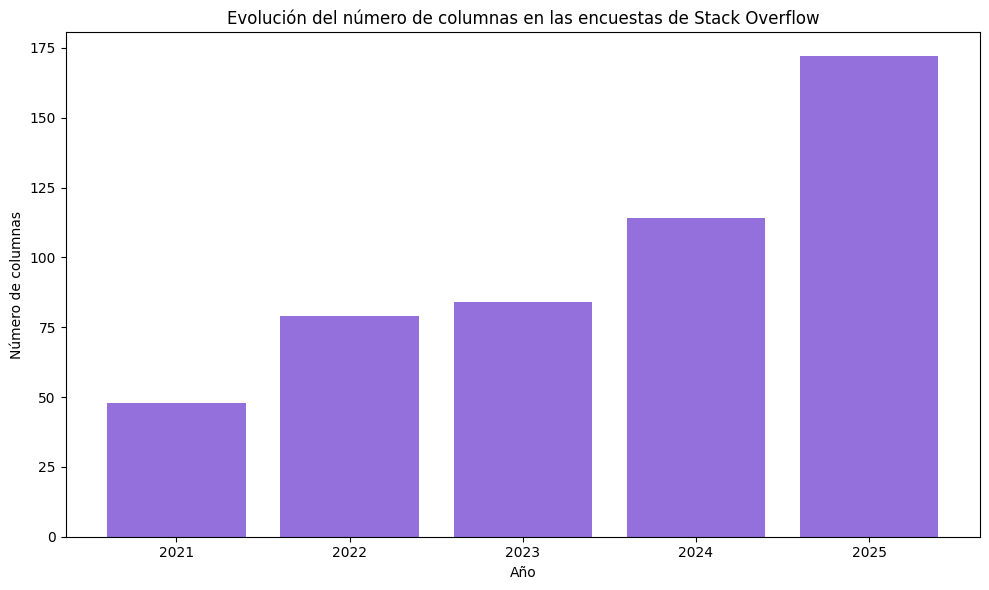

In [ ]:

df_columns = pd.DataFrame({
    'Año': [2021, 2022, 2023, 2024, 2025],
    'Número_Columnas': [len(df_stack_21.columns), len(df_stack_22.columns), len(df_stack_23.columns), len(df_stack_24.columns), len(df_stack_25.columns)]
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_columns['Año'], df_columns['Número_Columnas'], color='mediumpurple')
ax.set_xlabel('Año')
ax.set_ylabel('Número de columnas')
ax.set_title('Evolución del número de columnas en las encuestas de Stack Overflow')
plt.tight_layout()
plt.show()

Aquí podemos ver como la encueta se ha ido ampliando para concretar las preguntas, añadir nuevas preguntas como a partir de 2023 icormporando una sección sobre IA.